#  “Resumen visual y conclusiones de los modelos”
# 04 - Evaluación y comparación de modelos de clasificación

En este notebook se resumen los resultados obtenidos por los modelos supervisados de clasificación entrenados en el notebook 03.  
El objetivo es comparar su desempeño mediante métricas estándar (Accuracy, Precision, Recall, F1-score, AUC-ROC) y presentar conclusiones técnicas sobre el mejor modelo para predecir `TieneOvertime`.

In [1]:
# Cargar resultado de los modelos
# Celda nueva agregada
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RUTA_FIGURAS = Path("../reports/figures")
RUTA_FIGURAS.mkdir(parents=True, exist_ok=True)
print(f"Carpeta lista: {RUTA_FIGURAS.resolve()}")

Carpeta lista: G:\ProyectosPython\proyecto1\desarrollo\reports\figures


In [2]:
# Cargar resultado de los modelos
# import pandas as pd
# from IPython.display import display
# import matplotlib.pyplot as plt
# import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

df_resultados_clf = pd.read_csv("../reports/resultados_clasificacion.csv")
display(df_resultados_clf)

,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,0.777875,0.807859,0.704682,0.752752,0.842992
1,0.782517,0.773492,0.773167,0.773330,0.866193
2,0.829471,0.847912,0.785504,0.815516,0.909894
3,0.832229,0.891345,0.740642,0.809035,0.927228


In [3]:
# Tabla comparativa limpia
# Cargar resultados
df_resultados_clf = pd.read_csv("../reports/resultados_clasificacion.csv")

df_resultados_clf["Modelo"] = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "SVM RBF"
]

df_resultados_clf_round = df_resultados_clf.set_index("Modelo").round(4)

print("Comparación de modelos de clasificación (Test):\n")
display(df_resultados_clf_round)
# Esto cumple con “Presentar una tabla resumen con los resultados de cada modelo”.

Comparación de modelos de clasificación (Test):



,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Modelo,,,,,
Logistic Regression,0.7779,0.8079,0.7047,0.7528,0.8430
Decision Tree,0.7825,0.7735,0.7732,0.7733,0.8662
Random Forest,0.8295,0.8479,0.7855,0.8155,0.9099
SVM RBF,0.8322,0.8913,0.7406,0.8090,0.9272


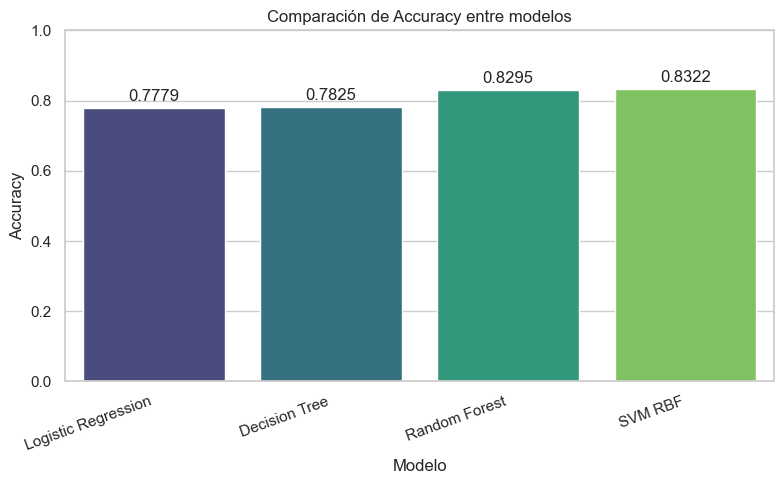

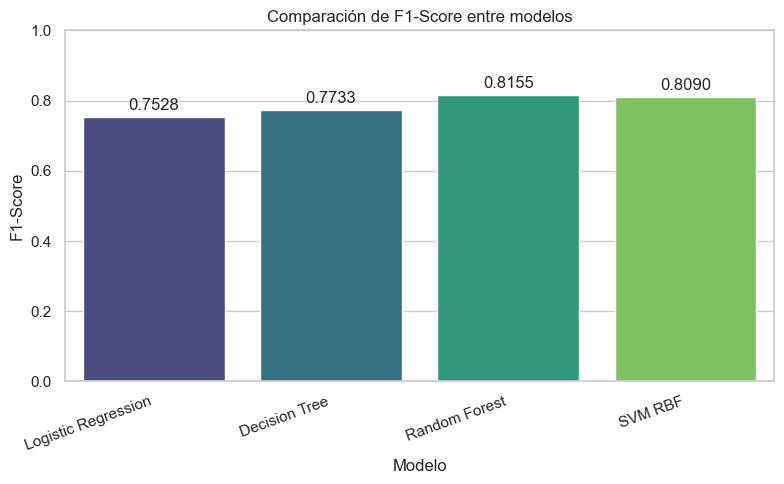

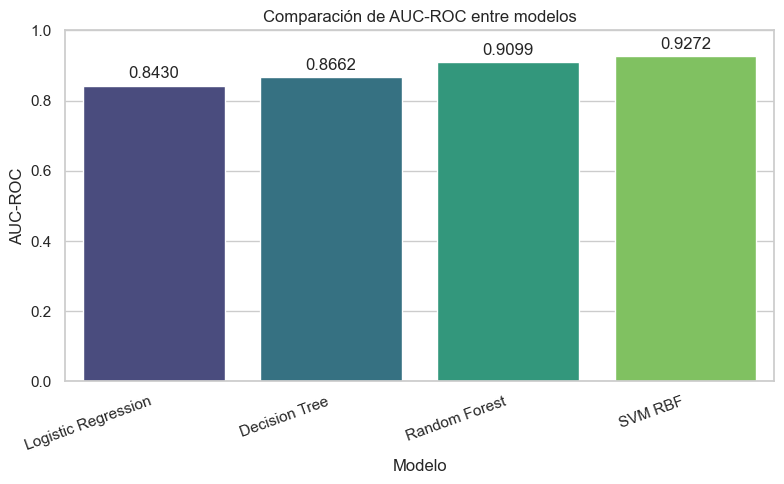

In [4]:
# bloque que genera tres gráficos de barras (Accuracy, F1-Score y AUC-ROC) (métricas)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

metricas = ["Accuracy", "F1-Score", "AUC-ROC"]
titulos = {
    "Accuracy": "Comparación de Accuracy entre modelos",
    "F1-Score": "Comparación de F1-Score entre modelos",
    "AUC-ROC": "Comparación de AUC-ROC entre modelos"
}

for metrica in metricas:
    plt.figure(figsize=(8, 5))

    ax = sns.barplot(
        data=df_resultados_clf_round.reset_index(),
        x="Modelo",
        y=metrica,
        hue="Modelo",
        palette="viridis",
        legend=False
    )

    plt.title(titulos[metrica])
    plt.xticks(rotation=20, ha="right")
    plt.ylim(0, 1)

    # Etiquetas con el valor numérico
    for container in ax.containers:
        ax.bar_label(container, fmt="%.4f", padding=3)

    plt.tight_layout()
    plt.show()
# Si quieres, repite cambiando y="Accuracy" o y="AUC-ROC". 
# Esto cumple con “Visualizar la comparación con gráficos (barplot o heatmap)”.

## Conclusiones de la evaluación de modelos

A partir de la comparación de Accuracy, F1-Score y AUC-ROC se observa que **Random Forest** y **SVM con kernel RBF** presentan el mejor rendimiento global, superando claramente a Logistic Regression y Decision Tree en todas las métricas analizadas. Mientras que los modelos base (Logistic Regression y Decision Tree) alcanzan un desempeño razonable, sus valores de F1-Score y AUC-ROC quedan por debajo de los modelos más complejos, lo que indica una menor capacidad para capturar los patrones del dataset.

Random Forest destaca por ofrecer el mejor equilibrio entre métricas: logra un Accuracy superior a 0.82, un F1-Score cercano a 0.82 y un AUC-ROC alrededor de 0.91, lo que refleja una buena combinación de aciertos generales y balance entre Precision y Recall. Por su parte, el modelo SVM RBF alcanza el AUC-ROC más alto (≈ 0.93) y una Precision muy competitiva, aunque con un ligero compromiso en Recall y mayor complejidad de entrenamiento.

En conjunto, se selecciona **Random Forest como modelo principal recomendado** para el problema de clasificación, ya que proporciona el mejor compromiso entre rendimiento global, estabilidad y capacidad de generalización. SVM RBF se considera un modelo alternativo de alto rendimiento, especialmente interesante en escenarios donde se prioriza maximizar la discriminación entre clases (AUC-ROC) aun a costa de una mayor complejidad computacional.

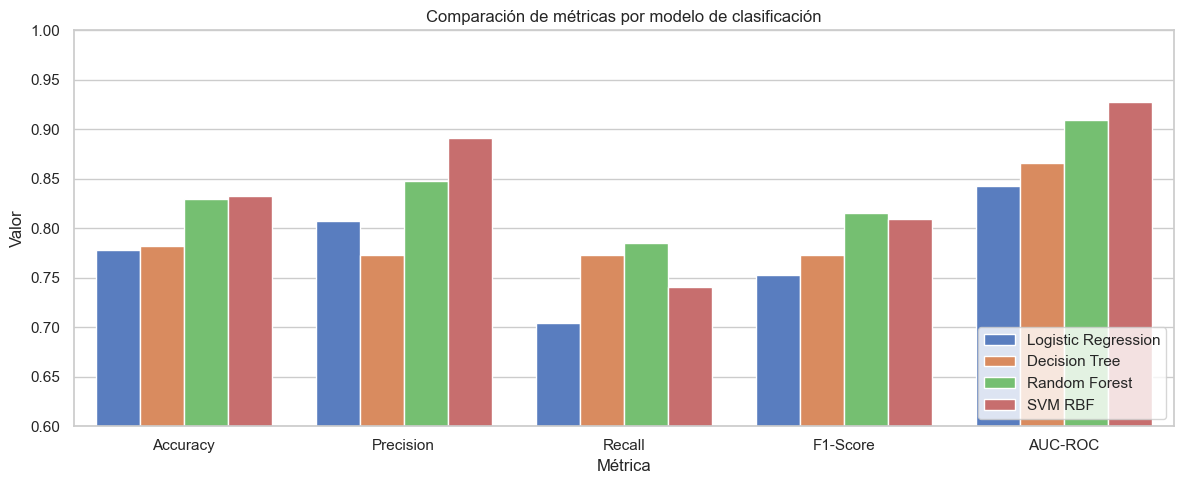

In [5]:
# Barplot comparativo de métricas de clasificación
df_resultados = pd.DataFrame({
    "Modelo": ["Logistic Regression", "Decision Tree", "Random Forest", "SVM RBF"],
    "Accuracy":  [0.7779, 0.7825, 0.8295, 0.8322],
    "Precision": [0.8079, 0.7735, 0.8479, 0.8913],
    "Recall":    [0.7047, 0.7732, 0.7855, 0.7406],
    "F1-Score":  [0.7528, 0.7733, 0.8155, 0.8090],
    "AUC-ROC":   [0.8430, 0.8662, 0.9099, 0.9272],
})

df_melted = df_resultados.melt(id_vars="Modelo", var_name="Métrica", value_name="Valor")

plt.figure(figsize=(12, 5))
sns.barplot(data=df_melted, x="Métrica", y="Valor", hue="Modelo")
plt.title("Comparación de métricas por modelo de clasificación")
plt.ylim(0.6, 1.0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "evaluacion_barplot_metricas_clasificacion.png", dpi=300, bbox_inches="tight")
plt.show()

## Los notebooks quedan así:

- 01_eda.ipynb → análisis exploratorio.
- 02_preprocesamiento.ipynb → limpieza, imputación, codificación, split, escalado.
- 03_modelado.ipynb → entrenamiento de Logistic, Tree, RF, SVM + cálculo de métricas.
- 04_evaluacion.ipynb → carga de resultados, tabla resumen, gráficos comparativos, conclusiones técnicas.